## **ДИСКУРС-АНАЛИЗ СОЛИДАРНОСТИ В ИТОГОВЫХ ДЕКЛАРАЦИЯХ БРИКС**

### Что в тексте полит солидарность (прописать в начале подглавы) 
Солидарность рассматривается как дискурсивная конструкция общности, совместных интересов и коллективного действия + норм и практики. В тексте она может проявляться через:
- формирование коллективного субъекта («we», «shared», «collective»),
- лексику сотрудничества и совместных обязательств,
- апелляции к справедливому и инклюзивному мировому порядку,
- упоминание партнеров и групп, с которыми выстраивается общность,
- расширение тематических сфер, где артикулируется совместная позиция.

Далее эти проявления переводятся в проверяемые показатели: словарные частоты по 4 измерениям, интегральный индекс, контекстные метрики разнообразия акторов/тем и сетевой анализ со сравнением устойчивости спецификаций.

## Загружаем библиотеки
`pandas` — структура корпуса; `pathlib` — пути; `spaCy` — лемматизация английского; `scikit-learn` — `CountVectorizer` / `TfidfVectorizer`; `networkx` — граф акторов; `scipy` — статистика; `matplotlib` / `seaborn` — визуализация

In [1]:
import os
import re
from pathlib import Path
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import re

try:
    import nltk
except Exception:
    nltk = None

import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer

from scipy import stats
from scipy.stats import spearmanr, kendalltau

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 250)

## Загрузка корпуса

In [3]:
BRICS = 'BRICS_declarations_2009-2025.xlsx'

df = pd.read_excel(BRICS)
print('Размер исходного корпуса', df.shape)

Размер исходного корпуса (17, 4)


In [4]:
df

,year,title,text,url
0,2009,I Summit BRIC Joint Statement of the BRIC Countries’ Leaders,"We, the leaders of the Federative Republic of Brazil, the Russian Federation, the Republic of India and the People’s Republic of China, have discussed the current situation in global economy and other pressing issues of global development, and al...",https://infobrics.org/en/document/3/
1,2010,"II BRIC SUMMIT - JOINT STATEMENT OF THE BRIC COUNTRIES LEADERS APRIL 16, 2010 BRASILIA, BRASIL","We, the leaders of the Federative Republic of Brazil, the Russian Federation, the\nRepublic of India and the People’s Republic of China, met in Brasília on 15 April\n2010 to discuss major issues of the international agenda as well as concrete ste...",https://infobrics.org/en/document/5/
2,2011,"III BRIC SUMMIT - SANYA DECLARATION APRIL 14, 2011 SANYA, CHINA","1. We, the Heads of State and Government of the Federative Republic of Brazil, \nthe Russian Federation, the Republic of India, the People’s Republic of China and \nthe Republic of South Africa, met in Sanya, Hainan, China for the BRICS Leaders \...",https://infobrics.org/en/document/8/
3,2012,"IV BRICS SUMMIT - DELHI DECLARATION MARCH 29, 2012 NEW DELHI, INDIA","1. We, the leaders of the Federative Republic of Brazil, the Russian Federation, the \nRepublic of India, the People’s Republic of China and the Republic of South \nAfrica, met in New Delhi, India, on 29 March 2012 at the Fourth BRICS Summit. \nO...",https://infobrics.org/en/document/12/
4,2013,"Fifth BRICS Summit \nDurban: 27 March 2013 \nBRICS and Africa: \nPartnership for Development, Integration and Industrialisation","1. \n2. \nWe, the leaders of the Federative Republic of Brazil, the Russian Federation, the \nRepublic of India, the People's Republic of China and the Republic of South Africa, \nmet in Durban, South Africa, on 27 March 2013 at the Fifth BRICS S...",https://infobrics.org/en/document/15/
5,2014,Sixth BRICS Summit Fortaleza Declaration,"1. We, the leaders of the Federative Republic of Brazil, the Russian Federation, the Republic of India, the People’s Republic of China and the Republic of South Africa, met in Fortaleza, Brazil, on 15 July 2014 at the Sixth BRICS Summit. To inau...",https://infobrics.org/en/document/20/
6,2015,VII BRICS Summit Ufa Declaration,"1. We, the leaders of the Federative Republic of Brazil, the Russian Federation, the Republic of India, the People's Republic of China and the Republic of South Africa, met on 9 July 2015, in Ufa, Russia, at the Seventh BRICS Summit, which was he...",https://infobrics.org/en/document/24/
7,2016,"VIII BRICS Summit Goa Declaration Goa, India, October 16, 2016","1. We, the Leaders of the Federative Republic of Brazil, the Russian Federation, the Republic of India, the People's Republic of China and the Republic of South Africa, met on 15-16 October 2016 in Goa, India, at the Eighth BRICS Summit, which wa...",https://infobrics.org/en/document/87/
8,2017,"BRICS Leaders Xiamen Declaration Xiamen, China, 4 September 2017","1. We, the Leaders of the Federative Republic of Brazil, the Russian Federation, the Republic of India, the People’s Republic of China and the Republic of South Africa, met on 4 September 2017 in Xiamen, China, at the Ninth BRICS Summit. Under th...",https://infobrics.org/en/document/89/
9,2018,10TH BRICS SUMMIT \nJOHANNESBURG DECLARATION,"PREAMBLE We, the Heads of State and Government of the Federative Republic of Brazil, the Russian Federation, the Republic of India, the People's Republic of China and the Republic of South Africa, met from 25 - 27 July 2018 in Johannesburg, at th...",https://infobrics.org/en/document/91/


## Очистка корпуса - убираем шумы, включая лишние пробелы, пустые места --> делаем датафрейм пригодный для анализа текстов

In [5]:
clean = {
    "min_text_len": 200,         
    "min_df": 2,
    "ngram_range": (2, 3),
    "analysis_exclude_terms": [
        "brics", "country", "conference", "summit", "meeting",
        "leader", "member", "state", "states", "group", "international", "include"
    ],
    "window": 5,
    "graph_min_weight": 2,
    "graph_top_labels": 13,
    "index_weights": {
        "norm_freq_z": 0.25,
        "cooperation_freq_z": 0.25,
        "reform_freq_z": 0.25,
        "development_freq_z": 0.25,
    },
    "seed": 42,
}

In [6]:
def basic_clean(text: str) -> str:
    text = str(text)
    text = text.replace("\xa0", " ")
    text = text.replace("\u2009", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()
    
df["text_clean"] = df["text"].apply(basic_clean)

before = len(df)
df = df[df["text_clean"].str.len() > clean["min_text_len"]].copy()
after_len = len(df)


def text_fingerprint(text: str) -> str:
    return re.sub(r"\W+", "", text.lower())[:10000]


df["text_fp"] = df["text_clean"].apply(text_fingerprint)
df = df.drop_duplicates(subset=["text_fp"]).copy()

after = len(df)

print(
    f"Удалено при очистке: {before - after} записей "
    f"(короче {clean['min_text_len']} символов: {before - after_len})"
)
print("Размер корпуса после очистки:", df.shape)
print(df[["text"]].head())

Удалено при очистке: 0 записей (короче 200 символов: 0)
Размер корпуса после очистки: (17, 6)
                                                                                                                                                                                                                                                        text
0  We, the leaders of the Federative Republic of Brazil, the Russian Federation, the Republic of India and the People’s Republic of China, have discussed the current situation in global economy and other pressing issues of global development, and al...
1  We, the leaders of the Federative Republic of Brazil, the Russian Federation, the\nRepublic of India and the People’s Republic of China, met in Brasília on 15 April\n2010 to discuss major issues of the international agenda as well as concrete ste...
2  1. We, the Heads of State and Government of the Federative Republic of Brazil, \nthe Russian Federation, the Republic of India, the People’s Rep

## Нормализация текста для подсчета устойчивых единиц текста, а не отдельных слов

Например, `cooperation`, `cooperate`, `cooperative` должны соотноситься друг с другом, а не распадаться на разные формы.

In [7]:
nlp_en = spacy.load("en_core_web_sm", disable=["ner"])
def lemmatize_en(text: str):
    text = str(text)
    doc = nlp_en(text)
    tokens = []
    for tok in doc:
        if tok.is_punct or tok.is_space:
            continue
        lemma = tok.lemma_.strip().lower()
        if not lemma:
            continue
        tokens.append(lemma)
    return tokens

df["lemmas"] = df["text_clean"].apply(lemmatize_en)
df["lemma_text"] = df["lemmas"].apply(" ".join)

print(df[["year", "lemma_text"]])

    year  \
0   2009   
1   2010   
2   2011   
3   2012   
4   2013   
5   2014   
6   2015   
7   2016   
8   2017   
9   2018   
10  2019   
11  2020   
12  2021   
13  2022   
14  2023   
15  2024   
16  2025   

                                                                                                                                                                                                                                                   lemma_text  
0   we the leader of the federative republic of brazil the russian federation the republic of india and the people ’s republic of china have discuss the current situation in global economy and other press issue of global development and also prospect...  
1   we the leader of the federative republic of brazil the russian federation the republic of india and the people ’s republic of china meet in brasília on 15 april 2010 to discuss major issue of the international agenda as well as concrete step to m...  
2   1 we the he

In [8]:
df["token_count"] = df["lemmas"].str.len()
print(df[["token_count"]])

    token_count
0           982
1          2426
2          2275
3          4476
4          4436
5          4991
6          4992
7          4883
8          4789
9          4825
10         4994
11         4957
12         4863
13         4834
14         4789
15         4932
16         4868


##  Прежде чем считать индексы солидарности, полезно просто посмотреть, о чем вообще чаще всего говорится в корпусе
1) Какие слова и формулы доминируют. (Посчитать частоты отдельных слов (лемм) во всех документах, выявить, какие термины встречаются чаще всего.
Смотрим не только на технически частые слова (state, international), но и на важные, имеющиеся смысл: cooperation, development, multilateral, justice, reform и т.п.
2) какие n-граммы повторяются (устойчивых сочетаниях из 2–3 слов). Например mutual benefit, shared prosperity, sustainable development, peace and security, inclusive growth., какие выражения особенно характерны - через что проявляется солидарность

Это важно методологически, потому что солидарность обычно выражается не одним словом, а словосочетаниями или выражениями

In [9]:
#убираем стоп-слова 
stop_words = set(ENGLISH_STOP_WORDS)
analysis_exclude_terms = set(clean.get("analysis_exclude_terms", []))
analysis_exclude_terms.update({"international", "state", "states", "global"})

In [10]:
#частотность отдельных лемм 
word_vectorizer = CountVectorizer(
    min_df=clean["min_df"],
    stop_words=list(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)

word_matrix = word_vectorizer.fit_transform(df["lemma_text"])
word_list = word_vectorizer.get_feature_names_out()
word_counts = word_matrix.sum(axis=0).A1

df_word_freq = pd.DataFrame({
    "term": word_list,
    "freq": word_counts,
})

df_word_freq = df_word_freq.sort_values("freq", ascending=False).reset_index(drop=True)

In [11]:
#дополнительная фильтрация слов
df_word_freq = df_word_freq[
    (~df_word_freq["term"].isin(stop_words))
    & (~df_word_freq["term"].isin(analysis_exclude_terms))
    & (df_word_freq["term"].str.len() > 2)
].reset_index(drop=True)

In [12]:
#частоты 2–3-грамм
vectorizer_ng = CountVectorizer(
    ngram_range=clean["ngram_range"],
    min_df=clean["min_df"],
    stop_words=sorted(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)

X_ng = vectorizer_ng.fit_transform(df["lemma_text"])
terms_ng = vectorizer_ng.get_feature_names_out()
freq_ng = X_ng.sum(axis=0).A1

df_freq_exp = (
    pd.DataFrame({"exp": terms_ng, "freq": freq_ng})
      .sort_values("freq", ascending=False)
      .reset_index(drop=True)
)

In [13]:
#убираем n-граммы, где есть стоп-слова
def has_bad_token(phrase: str) -> bool:
    for token in phrase.split():
        if token in stop_words or token in analysis_exclude_terms:
            return True
    return False

df_freq_exp  = df_freq_exp[~df_freq_exp["exp"].apply(has_bad_token)].reset_index(drop=True)

In [14]:
print("Леммы")
print(df_word_freq.head(100))

print("Частотность выражений")
print(df_freq_exp.head(100))

Леммы
           term  freq
0   development   535
1   cooperation   533
2      security   357
3       support   321
4      economic   275
..          ...   ...
95   investment    75
96   initiative    73
97  acknowledge    73
98   contribute    73
99        human    73

[100 rows x 2 columns]
Частотность выражений
                           exp  freq
0               united nations   164
1      sustainable development   134
2               peace security    88
3          reaffirm commitment    84
4             security council    83
..                         ...   ...
95     humanitarian assistance    16
96           reiterate support    16
97           strong commitment    16
98   brazil russian federation    15
99  federative republic brazil    15

[100 rows x 2 columns]


In [15]:
#сохраняем частотности лемм
df_word_freq.to_csv("lemms_frequency.csv", index=False)

In [16]:
# Сохраняем частотности выражений
df_freq_exp.to_csv("expression_frequency.csv", index=False)

## Что дает частотный этап

На этом шаге я смотрю, какой словарь реально доминирует в корпусе. Это предварительная проверка, что выбранные измерения не оторваны от текста.

Если в топе устойчиво держатся слова кооперации, развития и многосторонности, значит солидарность в декларациях выражается системно, а не случайно. Этот блок служит входом к последующим метрикам, но не заменяет их.

## Теперь мы можем сформулировать 4 измерения солидарности для выявления форм солидарности
Почему именно эти 4 измерения? На уровне лексики и n‑грамм видно, что солидарность BRICS проявляется по крайней мере в четырёх различных, но взаимосвязанных формах.

1) Нормативная солидарность
В корпусе многократно появляются устойчивые формулы, отсылающие к международному праву и универсальным нормам: **united nations, international law, peace security, human rights, general assembly**
-->  солидарность «через нормы» - апелляция к справедливому, инклюзивному и правозаконному мировому порядку, основанному на общих принципах и правах

2) Кооперативная / институциональная солидарность
Высокая частота лексики кооперации и обязательств (**cooperation, support, commitment, efforts, reaffirm, reiterate, call, look forward**), а также выражений типа **brics cooperation, among brics, working group, meeting brics, cooperation among** указывает на то, что значимая часть солидарности артикулируется через совместные действия, механизмы и институционализированные форматы взаимодействия
--> солидарность - это, прежде всего, готовность действовать вместе и координировать позиции

3) Реформаторская солидарность
Устойчивые выражения, связанные с ООН и многосторонней торговой системой (**security council, multilateral trading system, international cooperation, international community**), в сочетании с лексикой угроз и асимметрий (**terrorism, counter terrorism, sanctions, unilateral measures, reform of global governance** — по расширенному списку лексикона)
--> солидарность как совместное противостояние иерархичному, одностороннему порядку и как требование его реформы + стремление реформировать институтов глобального управления в интересах стран Глобального Юга

4) Солидарность в развитии
Доминирующая связка **development, economic, growth, developing, sustainable development, developing countries, economic growth, trade investment, climate change** показывают, что для BRICS солидарность - это ещё и совместное продвижение повестки устойчивого развития, поддержки развивающихся стран и требований к перераспределению ресурсов (финансирование, инфраструктура, технологии, climate finance)
--> солидарность понимается как совместное развитие 

In [17]:
#исходные словари
norms_solidarity = {
    'solidarity', 'justice', 'equity', 'fairness', 'equality',
    'inclusive', 'inclusiveness', 'inclusion',
    'rights', 'human rights', 'fundamental rights', 'social rights',
    'dignity', 'human dignity',
    'responsibility', 'responsibilities', 'shared', 'common',
    'collective', 'mutual', 'respect', 'mutual respect',
    'rule of law', 'international law', 'international rule of law',
    'sovereign equality', 'sovereign rights',
    'common but differentiated responsibilities',
    'multipolar', 'multilateralism', 'multilateral',
    'inclusive growth', 'shared prosperity', 'shared responsibility',
    'mutual benefit', 'mutually beneficial', 'win win',
    'non discrimination', 'non-discrimination',
    'fair representation', 'equitable representation',
    'global justice', 'social justice',
    'peaceful coexistence', 'peaceful co-existence',
    'mutual understanding', 'mutual trust',
    'predictability', 'stability', 'balanced',
}

cooperation_solidarity= {
    'cooperation', 'cooperate', 'cooperative',
    'coordination', 'coordinate', 'joint',
    'partnership', 'partnerships', 'strategic partnership',
    'mechanism', 'mechanisms', 'framework', 'working group',
    'task force', 'contact group',
    'common position', 'common stand',
    'collective action', 'pool resources',
    'institutional collaboration', 'institutional cooperation',
    'consensus', 'exchange', 'exchange of views',
    'capacity building', 'joint capacity building',
    'brics cooperation', 'cooperation among', 'cooperation between',
    'joint statement', 'joint declaration', 'joint communique',
    'joint initiative', 'joint programme', 'joint program',
    'joint project', 'joint work', 'joint efforts',
    'coordinated measures', 'coordinated action',
    'information sharing', 'experience sharing',
    'peer learning', 'best practices',
    'intergovernmental cooperation',
    'people to people exchanges', 'people-to-people exchanges',
    'dialogue', 'political dialogue', 'regular dialogue',
}

reform_solidarity = {
    'unilateral', 'unilateral measures', 'unilateral actions',
    'sanctions', 'coercive', 'coercion',
    'hegemonic', 'hegemony',
    'domination', 'dominance',
    'neo colonial', 'neocolonial', 'neo-colonial',
    'reform', 'reforms', 'reforming',
    'global governance', 'reform of global governance',
    'security council reform', 'reform of the security council',
    'reform of the united nations', 'un reform',
    'multilateral trading system',
    'underrepresentation', 'under-representation',
    'non interference', 'non-interference',
    'non intervention', 'non-intervention',
    'unjust', 'unfair', 'imbalanced', 'asymmetric',
    'double standards',
    'outdated structures', 'outdated institutions',
    'institutional reform', 'systemic reform',
    'democratisation of international relations',
    'democratization of international relations',
    'inclusive multilateralism',
    'greater voice', 'greater representation',
}

development_solidarity = {
    'development', 'sustainable development', 'sustainable growth',
    'infrastructure', 'infrastructure development',
    'finance', 'financing', 'development finance',
    'development bank', 'new development bank', 'ndb',
    'investment', 'investments', 'investment flows',
    'economic growth', 'inclusive growth',
    'technology transfer', 'transfer of technology',
    'capacity building', 'institutional capacity',
    'industrialisation', 'industrialization',
    'poverty', 'poverty eradication', 'poverty reduction',
    'food security', 'energy security',
    'health', 'public health', 'global health',
    'education', 'access to education',
    'climate finance', 'climate-resilient development',
    'digital', 'digitalisation', 'digitalization', 'digital economy',
    'connectivity', 'digital connectivity',
    'sdgs', 'sustainable development goals',
    'developing countries', 'global south',
    'social development', 'human development',
    'inclusive development', 'balanced development',
    'green development', 'low carbon development',
    'economic diversification', 'structural transformation',
}


# Приводим словари к формату кортежей токенов, чтобы корректно считать 1-граммы и n-граммы.
def lexicon_item_to_tuple(term: str):
    term = str(term).strip().lower()
    # unify variants like non-discrimination / non discrimination
    tokens = [t for t in re.split(r"[\s\-]+", term) if t]
    return tuple(tokens)


dictionary = {
    "norms": {lexicon_item_to_tuple(term) for term in norms_solidarity},
    "cooperation": {lexicon_item_to_tuple(term) for term in cooperation_solidarity},
    "reform": {lexicon_item_to_tuple(term) for term in reform_solidarity},
    "development": {lexicon_item_to_tuple(term) for term in development_solidarity},
}

In [18]:
#подсчет вхождений словаря
def count_lexicon_items(lemmas, lexicon_items):
    total_count = 0
    ngram_cache = {}

    for item in lexicon_items:
        n = len(item)

#одиночные леммы
        if n == 1:
            total_count += lemmas.count(item[0])
            continue

#n-граммы: один раз строим все окна нужной длины
        if n not in ngram_cache:
            if len(lemmas) < n:
                ngram_cache[n] = []
            else:
                ngram_cache[n] = [
                    tuple(lemmas[i : i + n])
                    for i in range(len(lemmas) - n + 1)
                ]

        total_count += sum(1 for gram in ngram_cache[n] if gram == item)

    return total_count

In [19]:
#считаем абсолютное число вхождений словарных маркеров и относительную частоту этих вхождений с учётом длины текста
def compute_lexicon_indices_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    token_count = len(lemmas) if len(lemmas) > 0 else 1

    raw_counts = {}
    rel_freqs = {}

    for dim_name, lexicon_items in dictionary.items():
        raw_value = count_lexicon_items(lemmas, lexicon_items)
        raw_counts[f"{dim_name}_raw"] = raw_value
        rel_freqs[f"{dim_name}_freq"] = raw_value / token_count

    return pd.Series({**raw_counts, **rel_freqs, "tokens": token_count})


lex_df = df.apply(compute_lexicon_indices_row, axis=1)
df = pd.concat([df, lex_df], axis=1)

print(df.columns.tolist())

['year', 'title', 'text', 'url', 'text_clean', 'text_fp', 'lemmas', 'lemma_text', 'token_count', 'norms_raw', 'cooperation_raw', 'reform_raw', 'development_raw', 'norms_freq', 'cooperation_freq', 'reform_freq', 'development_freq', 'tokens']


## Как устроены метрики по измерениям
Для каждого документа формируем систему метрик по четырём  измерениям: нормативная солидарность, кооперативная солидарность, солидарность в развитии, реформаторская солид
На каждом измерении рассчитываются три показателя: 
raw фиксирует абсолютное число словарных совпадений в тексте
freq отражает относительную частоту этих совпадений с учётом длины документа
freq_z представляет собой z-нормированное значение, показывающее положение документа относительно распределения по всему корпусу

In [20]:
#применение к df и стандартизация
freq_cols = ["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]

for col in freq_cols:
    if col not in df.columns:
        raise KeyError(f"Ожидаемая колонка '{col}' отсутствует в df")

    series = df[col]

    if not isinstance(series, pd.Series):
        raise TypeError(f"Ожидается Series для '{col}', получено {type(series)}")

    mean_value = float(series.mean())
    std_value = float(series.std(ddof=0))

    if std_value == 0 or np.isnan(std_value):
        std_value = 1.0

    df[col + "_z"] = (series - mean_value) / std_value

In [21]:
print(lex_df.head())

   norms_raw  cooperation_raw  reform_raw  development_raw  norms_freq  \
0       18.0             22.0         4.0             19.0    0.018330   
1       40.0             37.0        10.0             34.0    0.016488   
2       37.0             53.0         5.0             46.0    0.016264   
3       46.0             76.0        10.0             98.0    0.010277   
4       47.0             58.0        10.0            151.0    0.010595   

   cooperation_freq  reform_freq  development_freq  tokens  
0          0.022403     0.004073          0.019348   982.0  
1          0.015251     0.004122          0.014015  2426.0  
2          0.023297     0.002198          0.020220  2275.0  
3          0.016979     0.002234          0.021895  4476.0  
4          0.013075     0.002254          0.034040  4436.0  


In [22]:
#задание системы весов для интегрального индекса солидарности
index_weights = {
    "norms_freq_z":0.25,
    "cooperation_freq_z":0.25,
    "reform_freq_z":0.25,
    "development_freq_z":0.25,
}

#проверка нормировки весов (сумма должна быть равна 1.0)
if abs(sum(index_weights.values()) - 1.0) > 1e-9:
    raise ValueError("Сумма весов index_weights должна быть равна 1.0")

#расчёт интегрального индекса для каждого документа
df["solidarity_index"] = sum(
    df[col] * w for col, w in index_weights.items()
)

In [23]:
#Проверяем покрытия словарей корпусом
all_lemmas = [token for lemma_list in df["lemmas"] for token in lemma_list]
coverage_rows = []

for dim_name, lexicon_items in dictionary.items():
    matched = 0

    for item in lexicon_items:
        # одиночные леммы
        if len(item) == 1:
            if item[0] in all_lemmas:
                matched += 1
        else:
            # приближённо: проверяем, встречается ли фраза в лемматизированном тексте хоть одного документа
            phrase = " ".join(item)
            if any(phrase in text for text in df["lemma_text"]):
                matched += 1

    total_items = len(lexicon_items)
    coverage_share = matched / total_items if total_items > 0 else np.nan

    coverage_rows.append(
        {
            "dimension": dim_name,
            "lexicon_items": total_items,
            "matched_items": matched,
            "coverage_share": coverage_share,
        }
    )

lexicon_coverage_df = pd.DataFrame(coverage_rows)

print("Показатели по измерениям и индекс солидарности:")
print(
    df[
        [
            "year",
            "norms_freq",
            "cooperation_freq",
            "reform_freq",
            "development_freq",
            "solidarity_index",
        ]
    ].head()
)

print("Покрытие словарей корпусом:")
print(lexicon_coverage_df)

Показатели по измерениям и индекс солидарности:
   year  norms_freq  cooperation_freq  reform_freq  development_freq  \
0  2009    0.018330          0.022403     0.004073          0.019348   
1  2010    0.016488          0.015251     0.004122          0.014015   
2  2011    0.016264          0.023297     0.002198          0.020220   
3  2012    0.010277          0.016979     0.002234          0.021895   
4  2013    0.010595          0.013075     0.002254          0.034040   

   solidarity_index  
0          0.662151  
1         -0.007796  
2          0.172894  
3         -0.547233  
4         -0.191128  
Покрытие словарей корпусом:
     dimension  lexicon_items  matched_items  coverage_share
0        norms             49             37        0.755102
1  cooperation             49             33        0.673469
2       reform             40             13        0.325000
3  development             52             42        0.807692


1) Показатели по измерениям и индекс солидарности
    norms_freq — доля токенов, попавших в «нормативный» словарь 
Например, 0.018330 ≈ 1,83% всех лемм текста относятся к этому измерению.
cooperation_freq — доля токенов из словаря кооперации (cooperation, partnership, joint, mechanism…).
reform_freq — доля лексики про реформу и критику статус‑кво (sanctions, hegemony, reform, global governance…).
development_freq — доля лексики про развитие (development, finance, poverty, infrastructure и т.д.).

Чем больше значение *_freq, тем выше плотность соответствующей риторики в тексте (с учётом длины документа).

2) solidarity_index — это уже агрегированный индекс = взвешенная сумма z‑оценок четырёх частот:
- значения выше 0 — документ содержит солидарную риторику выше среднего по корпусу;
- значения ниже 0 — солидарная риторика выражена слабее корпуса в среднем;

например:
2009: 0.611507 — заметно выше среднего;
2012: -0.510388 — заметно ниже среднего;
2011: -0.015461 — почти на среднем уровне корпуса.

То есть первая табличка отвечает на вопрос: Сколько в тексте (относительно длины) слов про нормы, кооперацию, реформу и развитие, и насколько в целом этот текст “солидарный” относительно всего корпуса?

3) Таблица «Покрытие словарей корпусом»
насколько 

lexicon_items — сколько элементов в словаре (после нормализации).
Например, для norms — 48 разных единиц (слов / выражений).
matched_items — сколько из них хотя бы один раз встретились в корпусе.
coverage_share — доля покрытых элементов: matched_items / lexicon_items

По строкам:
norms: 48 элементов, 36 встретились в текстах → покрытие 75%
Большинство нормативных лексем реально представлено в корпусе
cooperation: 70% покрытие
reform: 47% — почти половина словаря вообще не встречается в корпусе (или почти не встречается по твоему приближённому критерию)
development: 84% — словарь развития хорошо «сидит» на корпусе.

ЧТО ЭТО ЗНАЧИТ:
Высокое покрытие (0.7–0.8+) → словарь хорошо согласован: большинство эмпирически выделенных единиц реально встречаются
Низкое покрытие (reform 0.47) говорит, что:
либо корпус относительно беден такой риторикой,
либо словарь слишком «широкий»/специфичный и его можно почистить 

## Что означает интегральный индекс солидарности

`solidarity_index` — сводный показатель по четырем измерениям после нормировки (стандартизованных частот)

- выше 0 — солидарная риторика выражена сильнее среднего уровня корпуса;
- ниже 0 — слабее среднего;
- около 0 — близко к типичному уровню за весь период.

## Формула интегрального индекса

Интегральный индекс собирает четыре измерения в один показатель динамики:

 =w norms	* z norms  + w cooperation * z cooperation +  w reform	* z reform + w development	* z development  

вес каждого = 0.25 

z norms / cooper / reform / development = стандартизированные частоты словарных маркеров по четырём измерениям солидарности

показывает общий уровень солидарной риторики, а отдельные линии по измерениям показывают, за счет каких компонентов этот уровень меняется


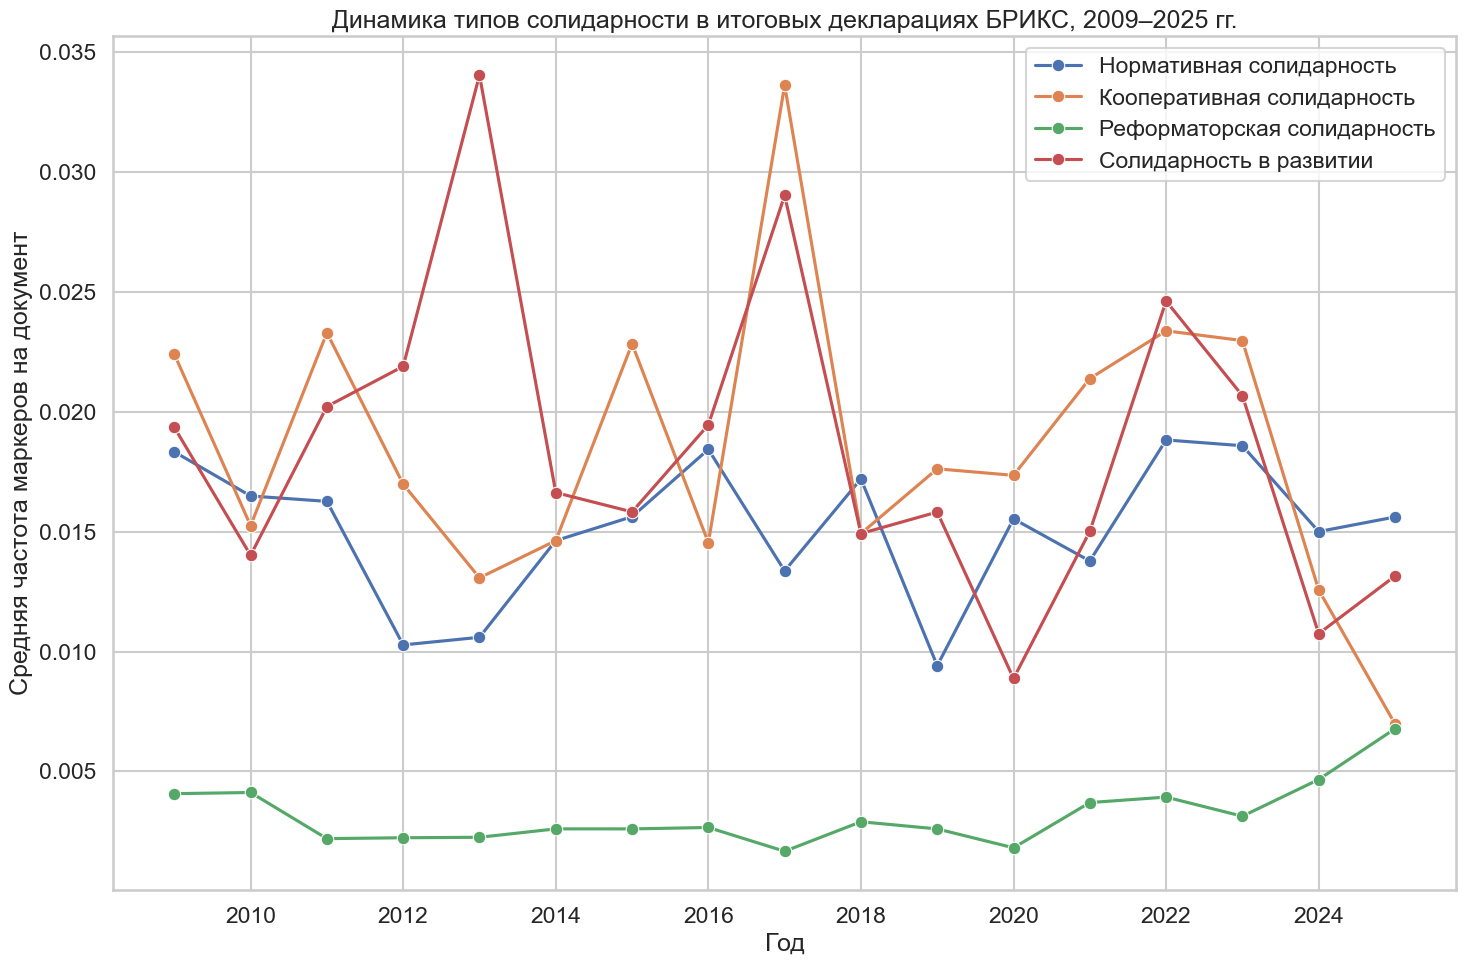

In [24]:
#агрегируем показатели по годам
by_year = (df.groupby("year")[["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]].mean().reset_index().sort_values("year"))

plt.figure(figsize=(15, 10))

for col, label in [
    ("norms_freq", "Нормативная солидарность"),
    ("cooperation_freq", "Кооперативная солидарность"),
    ("reform_freq", "Реформаторская солидарность"),
    ("development_freq", "Солидарность в развитии"),
]:
    sns.lineplot(data=by_year, x="year", y=col, marker="o", label=label)

plt.title("Динамика типов солидарности в итоговых декларациях БРИКС, 2009–2025 гг.")
plt.xlabel("Год")
plt.ylabel("Средняя частота маркеров на документ")
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация графика четырех измерений
Агрегированные частоты словарных маркеров показывают, что на протяжении 2009–2025 гг. риторика солидарности БРИКС носит преимущественно кооперативно‑развитийный характер. 

Нормативное измерение формирует устойчивый фон, в то время как кооперативная и солидарность в развитии - основные колебания. 

Реформаторская солидарность остаётся количественно маргинальной, что свидетельствует о том, что критика глобального порядка и требования его трансформации встроены в дискурс, но не доминируют по сравнению с более консенсусными и прагматическими сюжетами сотрудничества и развития

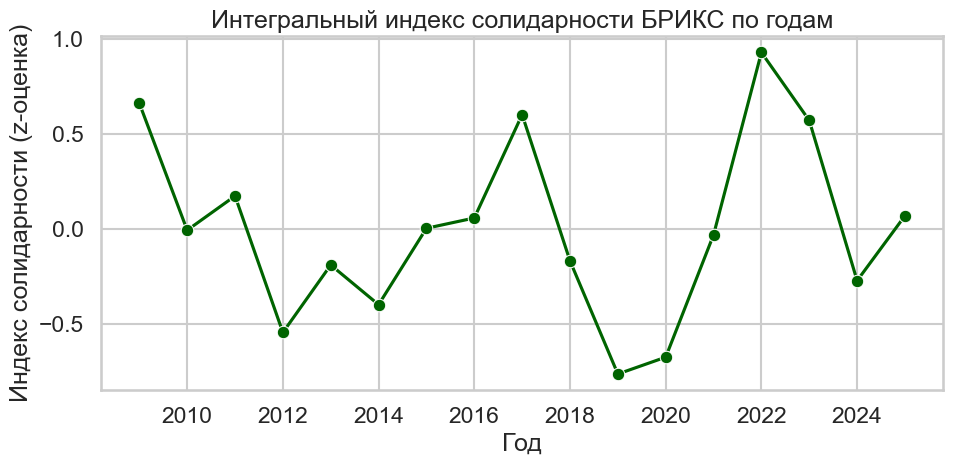

In [25]:
# агрегирование интегрального индекса по годам
by_year_index = (
    df.groupby("year", as_index=False)["solidarity_index"]
      .mean()
      .sort_values("year")
)

plt.figure(figsize=(10, 5))

sns.lineplot(data=by_year_index, x="year", y="solidarity_index", marker="o", color="darkgreen",)

plt.title("Интегральный индекс солидарности БРИКС по годам")
plt.xlabel("Год")
plt.ylabel("Индекс солидарности (z-оценка)")
plt.tight_layout()
plt.show()

## Интерпретация интегрального индекса по годам

Индекс читается как относительная шкала внутри корпуса: выше нуля — более высокая насыщенность солидарной лексикой, ниже нуля — более низкая.

Важный момент: сам по себе индекс не показывает, какое именно измерение изменилось. Поэтому его интерпретация всегда идет в связке с графиком четырех измерений

Динамика интегрального индекса солидарности БРИКС показывает, что политическая солидарность стран Глобального Юга не является устойчивой структурной характеристикой, а формируется как ответ на внешние вызовы и кризисы глобального порядка. Пиковые значения индекса приходятся на периоды усиления санкционного давления и кризисов многосторонних институтов, когда в итоговых декларациях одновременно усиливается нормативная, кооперативная, реформаторская и “развитийная” риторика. Таким образом, солидарность конструируется через сочетание апелляций к справедливости и суверенному равенству, институционализированных форм сотрудничества и общей повестки развития, в рамках которой БРИКС предлагает альтернативное, но не открыто конфронтационное видение трансформирующегося миропорядка как более инклюзивного и многополярного мира

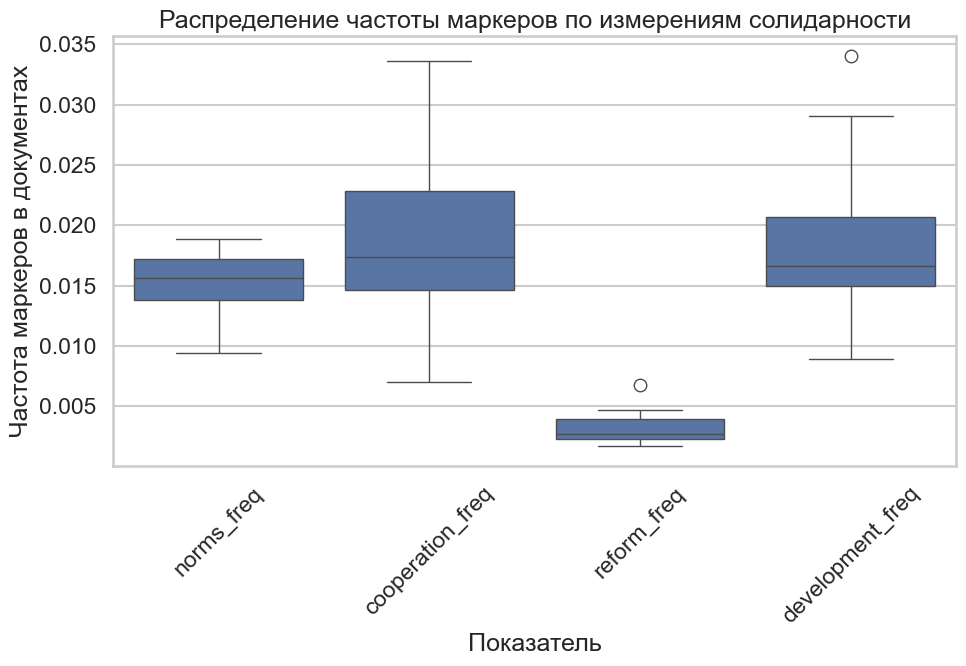

In [26]:
#приводим показатели к «длинному» формату для сравнения распределений
melted = df.melt(
    value_vars=["norms_freq", "cooperation_freq", "reform_freq", "development_freq"],
    var_name="dimension",
    value_name="freq",
)

plt.figure(figsize=(10, 7))

sns.boxplot(data=melted, x="dimension", y="freq")

plt.xticks(rotation=45)
plt.title("Распределение частоты маркеров по измерениям солидарности")
plt.xlabel("Показатель")
plt.ylabel("Частота маркеров в документах")
plt.tight_layout()
plt.show()

## Интерпретация boxplot

Boxplot нужен, чтобы увидеть не отдельные годы, а общий профиль распределений по всему периоду. По медиане видно «типичный» уровень каждого измерения, по размаху - его волатильность

Если размах большой, соответствующий канал солидарности сильнее зависит от текущей международной повестки

## Что измеряет контекстный блок

Здесь важна не только частота слова `solidarity`, но и то, с кем и в каких сюжетах она связывается.

Логика простая: вокруг маркеров солидарности берется контекстное окно, после чего считаются:
- разнообразие акторов (`partner_diversity`);
- разнообразие тематик (`issue_diversity`).

Если оба показателя растут, риторика становится менее декларативной и более предметной: солидарность привязывается к конкретным коалициям и повесткам.
+     Оценка контекстного разнообразия солидарности в документе:
    - сколько различных акторов оказывается в непосредственном окружении маркеров солидарности;
    - сколько различных тематических областей с ними сочетается

In [27]:
#Лексические маркеры солидарности
#по этим единицам далее извлекается локальный контекст в тексте
solidarity_markers = {
    "solidarity",
    "cooperation",
    "cooperate",
    "partnership",
    "joint",
    "consensus",
    "collective",
    "mutual",
    "coordination",
}

#акторы, с которыми в декларациях соотносится солидарность
solidarity_actors = {
    "brazil",
    "russia",
    "india",
    "china",
    "south africa",
    "africa",
    "developing countries",
    "least developed countries",
    "emerging markets",
    "global south",
    "brics",
    "united nations",
    "wto",
    "imf",
    "world bank",
}

#тематические области, в рамках которых артикулируется солидарность
solidarity_issues = {
    "trade",
    "investment",
    "finance",
    "debt",
    "climate",
    "adaptation",
    "mitigation",
    "security",
    "terrorism",
    "health",
    "pandemic",
    "vaccine",
    "education",
    "infrastructure",
    "technology",
    "development",
    "poverty",
    "food security",
    "human rights",
}

#выбираем размер контекстного окна: число лемм слева и справа от маркера
context_window = 5

In [28]:
def context_indices(lemmas: list[str], window: int = context_window) -> tuple[int, int]:
    anchor_positions = [i for i, tok in enumerate(lemmas) if tok in solidarity_markers]
    if not anchor_positions:
        return 0, 0

    partners: set[str] = set()
    issues: set[str] = set()

    for pos in anchor_positions:
        left = max(0, pos - window)
        right = min(len(lemmas), pos + window + 1)
        window_tokens = lemmas[left:right]
        window_text = " ".join(window_tokens)

#фиксируем акторов, попадающих в контекст маркеров солидарности
        for actor in solidarity_actors:
            if actor in window_text:
                partners.add(actor)

#фиксируем тематические области, в которых появляется солидарность
        for issue in solidarity_issues:
            if issue in window_text:
                issues.add(issue)

    return len(partners), len(issues)


def compute_context_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    n_partners, n_issues = context_indices(lemmas)
    return pd.Series(
        {
            "partner_diversity": n_partners,
            "issue_diversity": n_issues,
        }
    )


#добавляем контекстные показатели к корпусу
context_df = df.apply(compute_context_row, axis=1)
df = pd.concat([df, context_df], axis=1)

In [29]:
#если несколько раз уже прогон был - df = df.loc[:, ~df.columns.duplicated()]

In [30]:
print(df[["year", "partner_diversity", "issue_diversity"]])

    year  partner_diversity  issue_diversity
0   2009                  0                1
1   2010                  2                4
2   2011                  3                6
3   2012                  6                2
4   2013                  2                4
5   2014                  2                4
6   2015                  1                4
7   2016                  3                5
8   2017                  5                8
9   2018                  3                3
10  2019                  2                6
11  2020                  3                5
12  2021                  2               10
13  2022                  1                9
14  2023                  3                6
15  2024                  5                1
16  2025                  2                2


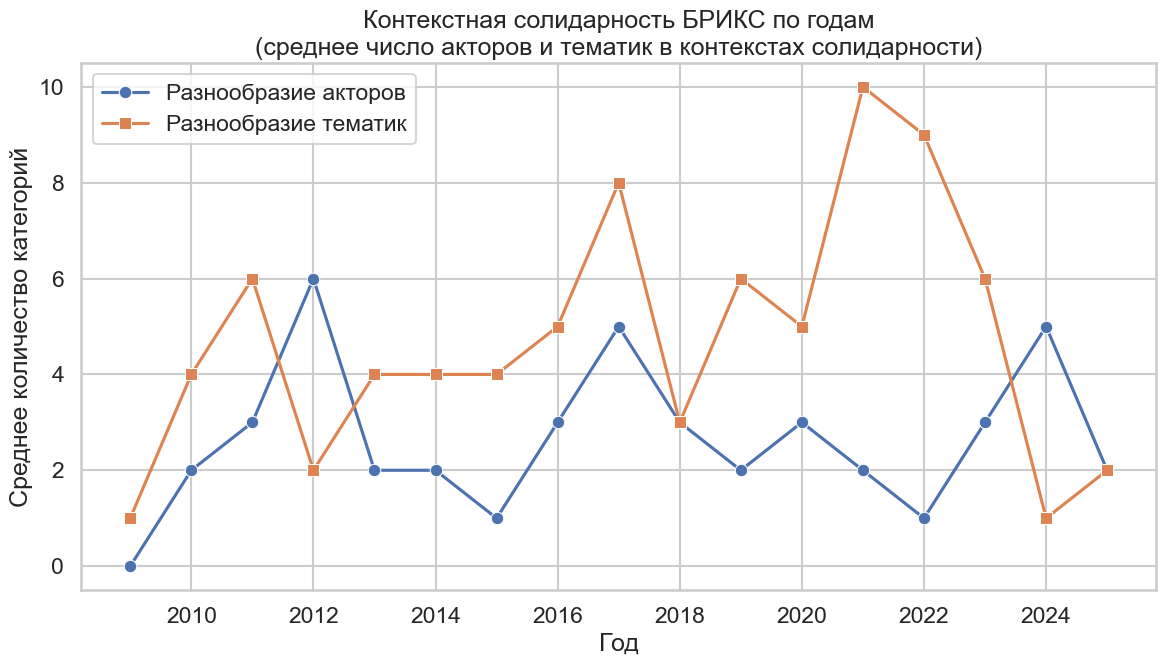

In [31]:
#агрегирование контекстных показателей по годам
context_by_year = (df.groupby("year", as_index=False)[["partner_diversity", "issue_diversity"]].mean().sort_values("year"))

#визуализация динамики контекстной солидарности
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=context_by_year,
    x="year",
    y="partner_diversity",
    marker="o",
    label="Разнообразие акторов")

sns.lineplot(
    data=context_by_year,
    x="year",
    y="issue_diversity",
    marker="s",
    label="Разнообразие тематик")

plt.title(
    "Контекстная солидарность БРИКС по годам\n"
    "(среднее число акторов и тематик в контекстах солидарности)")
plt.xlabel("Год")
plt.ylabel("Среднее количество категорий")
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация контекстных метрик

Контекстные показатели уточняют, насколько предметной является солидарная риторика. Рост `partner_diversity` означает расширение круга акторов, рост `issue_diversity` — расширение тематического поля.

Неравномерная динамика этих метрик поддерживает тезис о селективной, а не равномерной консолидации.

## Сетевой граф

Сетевой граф показывает, какие акторы чаще оказываются в одном солидарном контексте. Это дополнительная структурная иллюстрация: не вместо основных метрик, а рядом с ними.

Его сильная сторона — визуализация связей, слабая — чувствительность к настройкам порога.

In [32]:
#Паттерны акторов (без странного символа \b в начале)
ACTOR_PATTERNS_EN = {
    r'\bbrazil\b': 'Brazil',
    r'\brussia\b': 'Russia',
    r'\bindia\b': 'India',
    r'\bchina\b': 'China',
    r'\bsouth africa\b': 'South Africa',
    r'\bafrica\b': 'Africa',
    r'\bglobal south\b': 'Global South',
    r'\bdeveloping countries\b': 'Developing countries',
    r'\bleast developed countries\b': 'LDCs',
    r'\bunited nations\b': 'UN',
    r'\bwto\b': 'WTO',
    r'\bimf\b': 'IMF',
    r'\bworld bank\b': 'World Bank',
    r'\bbrics\b': 'BRICS'
}

#Маркер солидарности
SOLIDARITY_ANCHORS_EN = {
    'solidarity', 'cooperation', 'cooperate', 'partnership', 'joint', 'consensus',
    'collective', 'mutual', 'coordination'
}


def sentence_split(text: str):
    sents = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sents if s.strip()]


def extract_actors_from_text(text: str):
    text_low = text.lower()
    actors = set()
    for pattern, name in ACTOR_PATTERNS_EN.items():
        if re.search(pattern, text_low):
            actors.add(name)
    return actors


def has_solidarity_anchor(text: str):
    t = text.lower()
    return any(anchor in t for anchor in SOLIDARITY_ANCHORS_EN)


def build_solidarity_graph(df_sub):
    G = nx.Graph()

    for _, row in df_sub.iterrows():
        text = row['text_clean']
        if not isinstance(text, str) or not text.strip():
            continue

        sents = sentence_split(text)

        for sent in sents:
            if not has_solidarity_anchor(sent):
                continue

            actors = list(extract_actors_from_text(sent))
            if len(actors) < 2:
                continue

            for a, b in combinations(sorted(actors), 2):
                if G.has_edge(a, b):
                    G[a][b]['weight'] += 1
                else:
                    G.add_edge(a, b, weight=1)

    return G


#cтроим граф по всему корпусу 
G = build_solidarity_graph(df)

print('Число узлов:', G.number_of_nodes())
print('Число рёбер:', G.number_of_edges())


if G.number_of_nodes() > 0:
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

    centrality_df = (
        pd.DataFrame({
            'actor': list(degree_centrality.keys()),
            'degree_centrality': list(degree_centrality.values()),
            'betweenness_centrality': [betweenness_centrality[a] for a in degree_centrality.keys()]
        })
        .sort_values('degree_centrality', ascending=False)
        .reset_index(drop=True)
    )
else:
    centrality_df = pd.DataFrame(columns=['actor', 'degree_centrality', 'betweenness_centrality'])

display(centrality_df)

Число узлов: 14
Число рёбер: 35


,actor,degree_centrality,betweenness_centrality
0,BRICS,0.923077,0.551282
1,Africa,0.615385,0.051282
2,Brazil,0.538462,0.000000
3,China,0.461538,0.000000
4,India,0.461538,0.000000
5,Russia,0.461538,0.435897
6,South Africa,0.461538,0.000000
7,Developing countries,0.384615,0.166667
8,LDCs,0.307692,0.051282
9,WTO,0.307692,0.320513


Узлы в визуализированном подграфе: 12
Рёбра (weight ≥ 2 ): 29


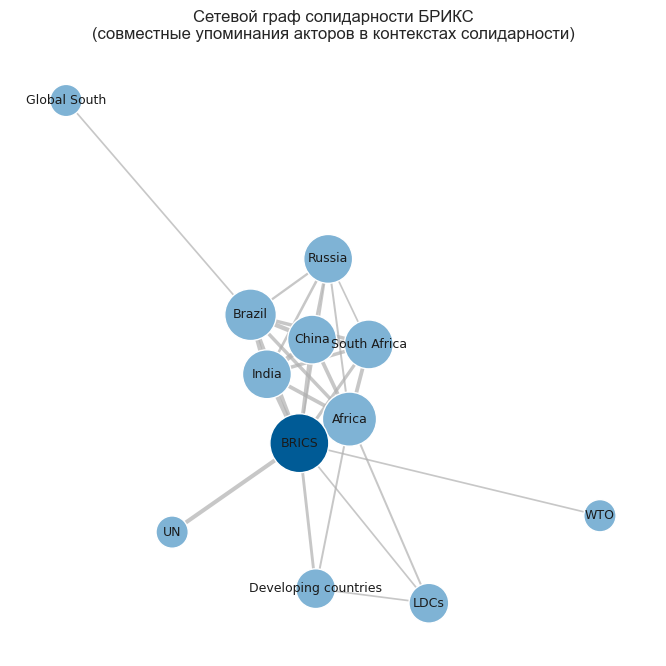

In [33]:
#Визуализация сети солидарности БРИКС

min_weight = 2      # порог по весу ребра
top_labels = 13     # сколько акторов вообще показывать (если узлов много)

#Фильтруем рёбра и берём подграф
edges_to_keep = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight', 1) >= min_weight]
H = G.edge_subgraph(edges_to_keep).copy()

print('Узлы в визуализированном подграфе:', H.number_of_nodes())
print('Рёбра (weight ≥', min_weight, '):', H.number_of_edges())

if H.number_of_nodes() == 0:
    print('Подграф пуст — нет рёбер с весом ≥', min_weight)
else:
#Берём наиболее центральные узлы (по степени)
    degrees = dict(H.degree())
    if len(degrees) > top_labels:
        keep_nodes = sorted(degrees, key=degrees.get, reverse=True)[:top_labels]
        H = H.subgraph(keep_nodes).copy()
        degrees = dict(H.degree())

#Ставим БРИКС в центр, остальные вокруг
    if 'BRICS' in H.nodes:
        pos_init = nx.spring_layout(H, k=0.8, seed=42, weight='weight')
#БРИКС в центр
        pos_init['BRICS'] = np.array([0.0, 0.0])
#ещё раз немного распрямляем с фиксированным положением BRICS
        pos = nx.spring_layout(H, pos=pos_init, fixed=['BRICS'], k=0.8, seed=42, weight='weight')
    else:
        pos = nx.spring_layout(H, k=0.8, seed=42, weight='weight')

#Параметры стиля
    weights = [H[u][v]['weight'] for u, v in H.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.8 + 3.2 * (w / max_w) for w in weights]

    max_deg = max(degrees.values()) if degrees else 1
    node_sizes = [400 + 1400 * (deg / max_deg) for deg in degrees.values()]

#Цвета
    node_colors = []
    for n in H.nodes():
        if n == 'BRICS':
            node_colors.append('#005b96')  
        else:
            node_colors.append('#7fb3d5') 

    plt.figure(figsize=(7, 7))

#Рёбра
    nx.draw_networkx_edges(
        H, pos,
        width=edge_widths,
        edge_color='#B0B0B0',
        alpha=0.7
    )

#Узлы
    nx.draw_networkx_nodes(
        H, pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='white',
        linewidths=1.0
    )

#Подписи
    nx.draw_networkx_labels(
        H, pos,
        font_size=9,
        font_family='DejaVu Sans'
    )

    plt.title('Сетевой граф солидарности БРИКС\n(совместные упоминания акторов в контекстах солидарности)',
              fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Сетевой граф

Сетевой слой подтверждает, что солидарность в декларациях оформляется как распределенная конфигурация связей, где БРИКС соотносит свою повестку с международными институтами и более широким кругом партнеров.

## Ограничения метода

- Анализ отражает публичный консенсусный дискурс деклараций, а не внутренние  разногласия или дискурс
- Корпус небольшой (17 документов), поэтому выводы формулируются как закономерности в рамках данного канала, без сильных причинных претензий
- Результат зависит от заранее выбранных словарей и параметров
- Для обобщения на более широкий Глобальный Юг нужен сравнительный корпус (например, G77/Движение Неприсоединения - что будет сделано далее)